In [1]:
#import umap
#import phate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.colors as mcol
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler
from matplotlib import ticker
import scipy.stats as sts
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy.ma as nma

plt.style.use('./presentation.mplstyle')


In [2]:
saga = pd.read_csv('saga-dr3-tableC2.txt', sep= r'\s+')
print(saga.shape)
saga = saga.reset_index()

sources = pd.read_csv('v1saga_dwarfs.csv')
print(sources.shape)

smorph = pd.read_csv('saga_morph.csv')
print(smorph.shape)

galex = pd.read_csv('v1GALEX_dwarfs.csv')
print(np.shape(galex))

(75704, 17)
(6337, 26)
(6211, 78)
(6337, 15)


In [3]:
sred = saga.loc[smorph['ind0']]

In [45]:
bands = {'g':[mcm.Blues,'tab:blue'],'r':[mcm.Greens,'tab:green'],'i':[mcm.Oranges,'tab:orange'],'z':[mcm.Reds,'tab:red']}

npr = {'gini':[[0.4,0.6],r'$Gini$',r'${\it Gini}$'],'m20':[[-2,-1],r'$M_{20}$',r'$M_{20}$'],
       'c':[[2,3.5],r'$Concentration$',r'${\it C_{CAS}}$'],'a':[[-0.3,0.3],r'$Asymmetry$',r'${\it A_{CAS}}$'],'s':[[-0.1,0.1],r'$Smoothness$',r'${\it S_{CAS}}$'],
       'rpetro':[[8,38],r'$Petrosian\ R$',r'$R_p$'],'n':[[0.0,4.0],r'$Sersic\ n$',r'${\it n}$'],'rhalf':[[0,20],r'$Sersic\ R$',r'$R_{0.5}$']}


In [8]:
gprop = pd.DataFrame()
#gprop['ind'],gprop['logM'],gprop['zspec']=sources['ind'],sources['logM'],sources['zspec']
gprop['ind']=sources['ind']
gprop['m_g0'],gprop['m_r0']=sources['m_g0'],sources['m_r0']
#gprop['log_ssfr'],gprop['flag_nondet']= galex['log_sfr']-gprop['logM'],galex['flag_nondet']
gprop['log_sfr'],gprop['log_sfr_err'],gprop['snr'],gprop['flag_nondet']= galex['log_sfr'],galex['log_sfr_err'],galex['snr'],galex['flag_nondet']
print(np.shape(gprop))

#del sources,galex

smerge = gprop.merge(right=smorph,how='left', left_on='ind', right_on='ind0')
print(smerge.shape)


(6337, 7)
(6337, 85)


In [9]:
smerge['ind'] = smerge['ind'].astype(int)
smerge

,ind,m_g0,m_r0,log_sfr,log_sfr_err,snr,flag_nondet,ind0,ind1,gini_g,...,segm_petr_z,xc_as_z,yc_as_z,rpetro_z,orien_as_z,ellip_as_z,n_z,rhalf_z,ellip_ss_z,flag_ss_z
0,71623,19.329632,18.930157,-0.935394,0.088813,11.259,False,71623.0,0.0,0.436354,...,0.854369,64.681096,63.267935,16.259123,-0.156145,0.004889,0.914716,5.148242,0.241027,0.0
1,71668,20.504047,20.101260,-1.422350,0.137626,3.878,True,71668.0,1.0,0.440125,...,1.128472,63.175212,63.820363,9.932680,0.969127,0.071231,3.347345,1.409869,0.865371,0.0
2,71673,19.500158,19.095045,-1.116916,0.098570,7.542,False,71673.0,2.0,0.505753,...,0.546638,64.223998,63.249787,22.902645,1.075276,0.159992,16.854054,19.767863,0.664864,2.0
3,71674,20.385132,19.952848,-1.590897,0.256516,1.782,True,71674.0,3.0,0.512487,...,1.218623,63.715355,63.143926,10.898795,-0.261603,0.331842,3.794210,3.138153,0.908137,0.0
4,71676,19.875254,19.544157,-1.199559,0.105172,6.361,False,71676.0,4.0,0.481103,...,1.184307,63.665631,63.250000,14.553917,1.101214,0.174298,1.736162,2.437790,0.404068,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6332,72057,20.410501,20.107954,-2.494889,0.097039,7.907,False,72057.0,6332.0,0.506872,...,0.404826,68.242532,62.273330,21.277647,-0.250194,0.474831,0.010000,9.483406,0.638338,1.0
6333,72062,20.514967,19.929909,-1.655102,0.135351,3.978,True,72062.0,6333.0,0.455545,...,1.298413,64.164120,64.170599,12.027413,-0.192648,0.303542,3.181663,3.193801,0.877374,0.0
6334,72063,19.868124,19.554760,-2.267471,0.086181,13.551,False,72063.0,6334.0,0.524255,...,1.036671,62.244343,62.745727,16.173181,1.386554,0.139588,1.970694,5.306116,0.292078,0.0
6335,72247,19.961090,19.789684,-0.748576,0.085165,14.870,False,72247.0,6335.0,0.454075,...,0.794411,64.280209,62.767269,15.534334,-0.570041,0.337333,1.293742,3.942506,0.844689,2.0


In [7]:
print(saga['index'])
print(smerge['ind0'])

0            0
1            1
2            2
3            3
4            4
         ...  
75699    75699
75700    75700
75701    75701
75702    75702
75703    75703
Name: index, Length: 75704, dtype: int64
0       71623
1       71668
2       71673
3       71674
4       71676
        ...  
6206    72057
6207    72062
6208    72063
6209    72247
6210    72308
Name: ind0, Length: 6211, dtype: int64


In [10]:
sfinal = sred.merge(right=smerge,how='left', left_on='index', right_on='ind0')
sfinal = sfinal.drop(columns=['ind','ind0','ind1'])
print(sfinal.shape)

(6211, 100)


In [12]:
sfinal
sfinal.to_csv("SAGAbg-morph.csv")

In [47]:
selc = smerge[(smerge['r20_psf_g']>0.5)&(smerge['snr_pix_g']>2.5)&(smerge['flag_g']<=1)&(smerge['snr_pix_r']>2.5)&(smerge['r20_psf_g']>0.5)&(smerge['flag_r']<=1)&(smerge['flag_nondet']==False)]
print(selc.shape)

penguin_data = selc[
    ['logM','zspec','log_ssfr','m_g0','m_r0','gini_g', 'm20_g','a_s_g', 'c_g','rpetro_g', 'n_g', 'rhalf_g',
    'gini_r', 'm20_r','a_s_r', 'c_r','rpetro_r', 'n_r', 'rhalf_r']].values

print(penguin_data.shape)
scaled_data = StandardScaler().fit_transform(penguin_data)

(2085, 85)
(2085, 19)


In [48]:
reducer = umap.UMAP(min_dist=0.2,n_neighbors=5)
embedding = reducer.fit_transform(scaled_data)
print(embedding.shape)

(2085, 2)


Text(0, 0.5, '$UMAP_2$')

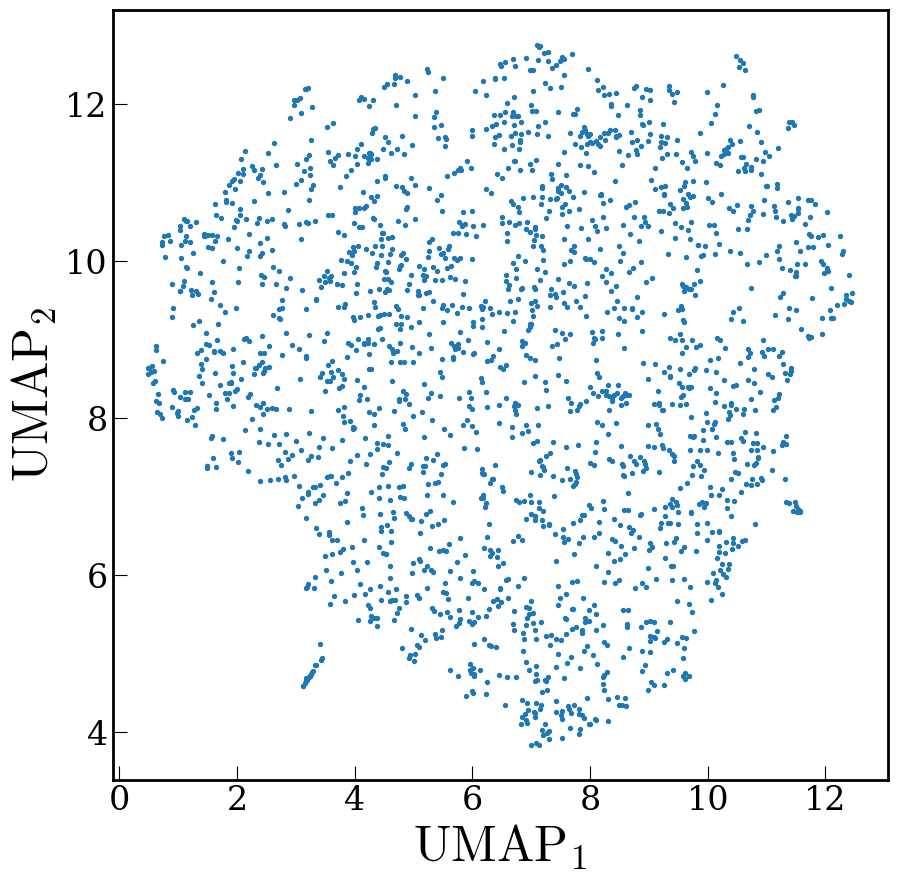

In [49]:
fig,ax=plt.subplots(figsize=(10,10))

ax.scatter(embedding[:,0],embedding[:,1],s=8)
ax.set_xlabel(r'$UMAP_1$',fontsize=36)
ax.set_ylabel(r'$UMAP_2$',fontsize=36)


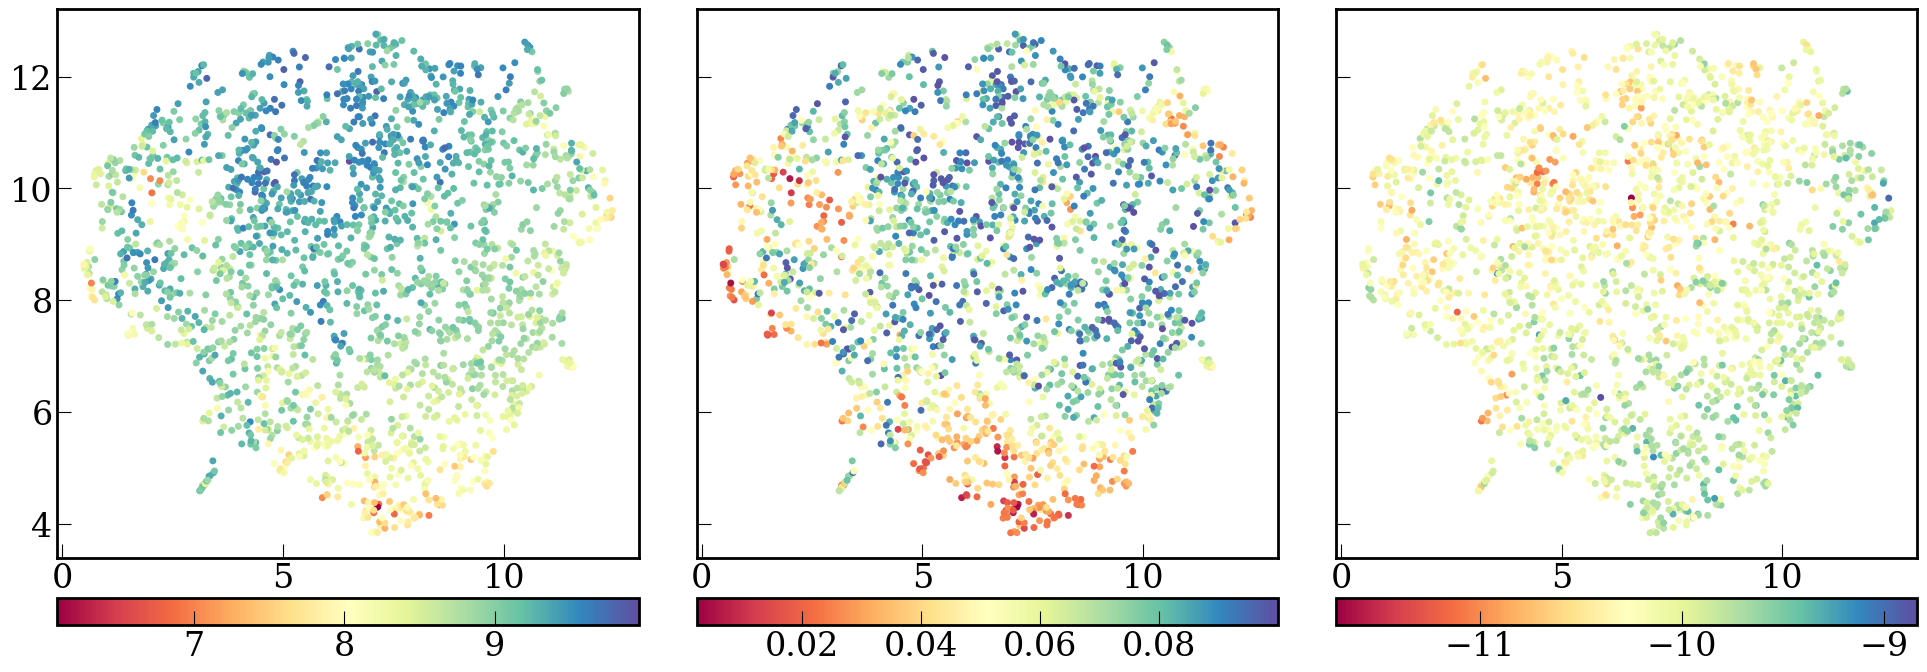

In [50]:
fig,ax=plt.subplots(1,3,figsize=(24,8),sharey='row',sharex='col')

target_key = ['logM','zspec','log_ssfr']
for j,ley in enumerate(target_key):
    im = ax[j].scatter(embedding[:,0],embedding[:,1],c=selc[target_key[j]],cmap=mcm.Spectral,s=16)
    ax[j].set_rasterized(True)

    divider = make_axes_locatable(ax[j])
    cax = divider.append_axes('bottom', size='5%', pad=0.4)
    fig.colorbar(im, cax=cax, orientation='horizontal')

plt.subplots_adjust(wspace=0.1)

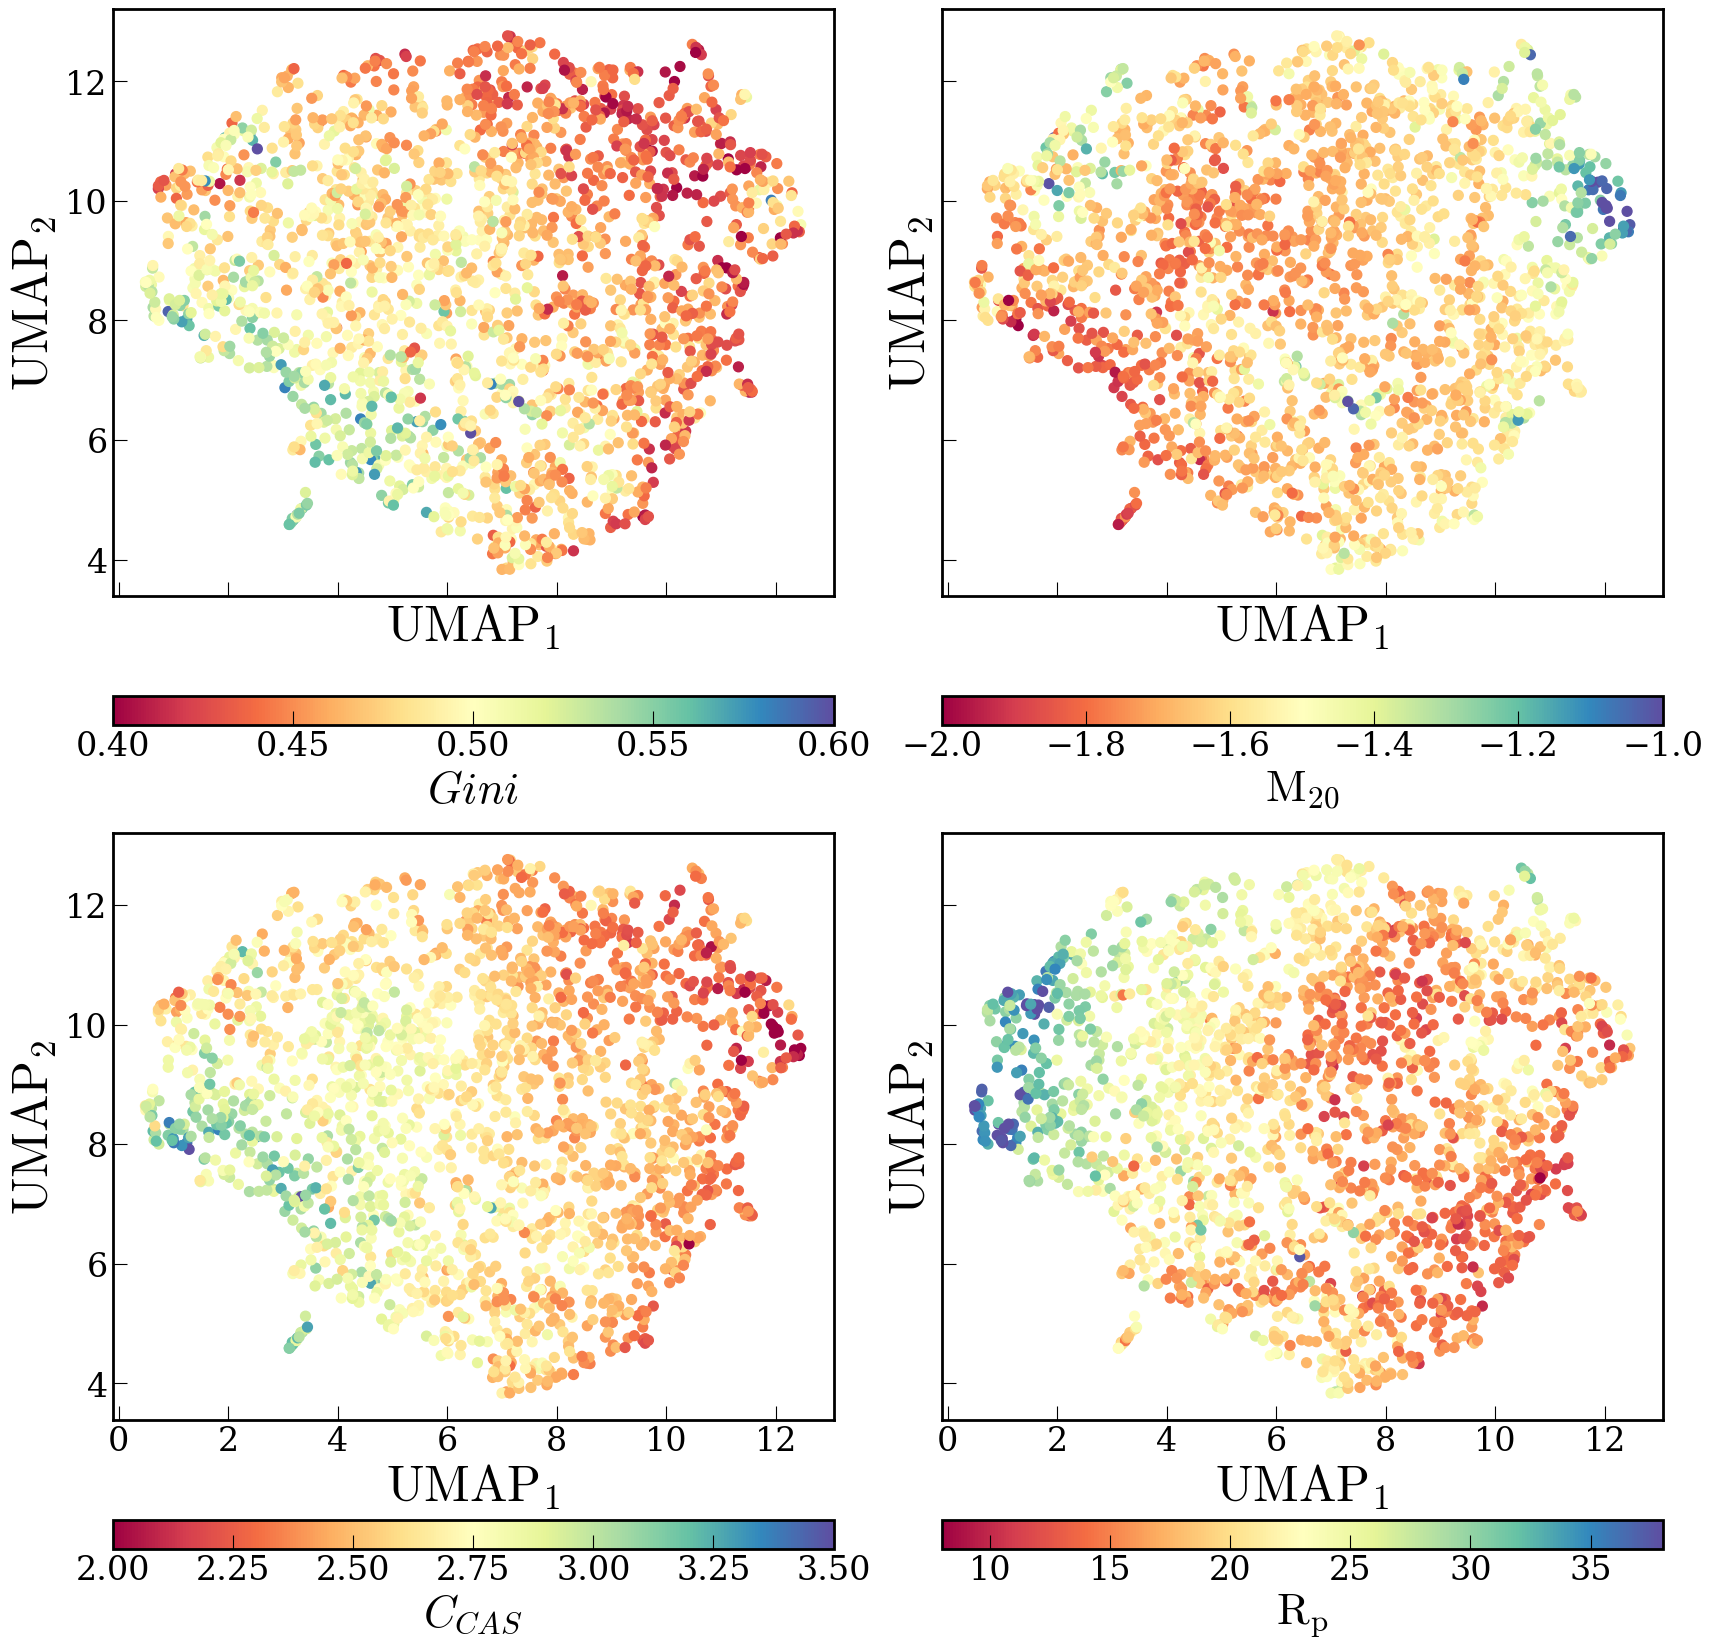

In [51]:
fig,ax=plt.subplots(2,2,figsize=(20,20),sharey='row',sharex='col')

key_list = list(npr.keys())
target_key = ['gini','m20','c','rpetro']
key_position = [key_list.index(t) for t in target_key]
    
for j,ley in enumerate(key_position):
    im = ax[j//2,j%2].scatter(embedding[:,0],embedding[:,1],c=selc[target_key[j]+'_r' ],cmap=mcm.Spectral,vmin=npr[key_list[ley]][0][0],vmax=npr[key_list[ley]][0][1],s=50)
    ax[j//2,j%2].set_rasterized(True)
    ax[j//2,j%2].set_xlabel(r'$UMAP_1$',fontsize=36)
    ax[j//2,j%2].set_ylabel(r'$UMAP_2$',fontsize=36)

    divider = make_axes_locatable(ax[j//2,j%2])
    cax = divider.append_axes('bottom', size='5%', pad=1.0)
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label(label=npr[key_list[ley]][2],size=32)

plt.subplots_adjust(hspace=0.15,wspace=0.15)
plt.savefig('UMAP.pdf',bbox_inches='tight')

In [13]:
phate_op = phate.PHATE(n_components=2,knn=5, decay=20)
Y = phate_op.fit_transform(scaled_data)

Calculating PHATE...
  Running PHATE on 2085 observations and 17 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.03 seconds.
    Calculating affinities...
    Calculated affinities in 0.03 seconds.
  Calculated graph and diffusion operator in 0.06 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.10 seconds.
    Calculating KMeans...
    Calculated KMeans in 0.86 seconds.
  Calculated landmark operator in 0.96 seconds.
  Calculating optimal t...
    Automatically selected t = 29
  Calculated optimal t in 0.91 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.32 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 4.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 1.04 seconds.
Calculated PHATE in 3.43 seconds.


Text(0, 0.5, '$PHATE_2$')

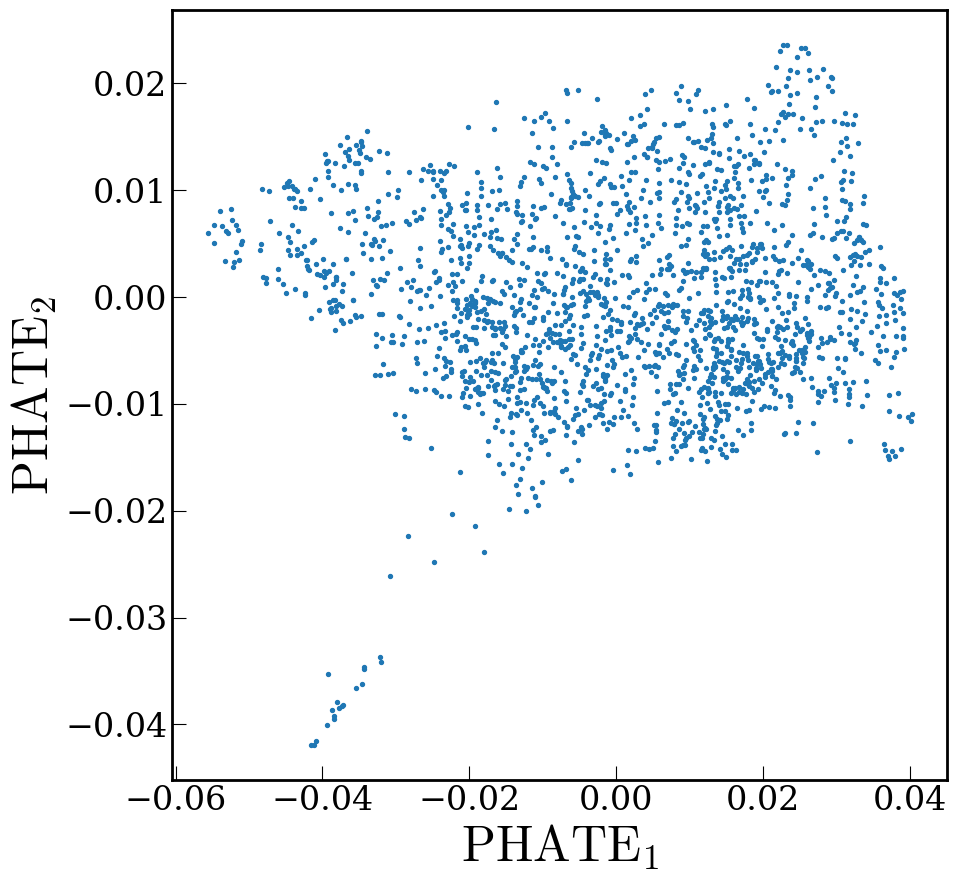

In [14]:
fig,ax=plt.subplots(figsize=(10,10))

ax.scatter(Y[:,0],Y[:,1],s=8)
ax.set_xlabel(r'$PHATE_1$',fontsize=36)
ax.set_ylabel(r'$PHATE_2$',fontsize=36)


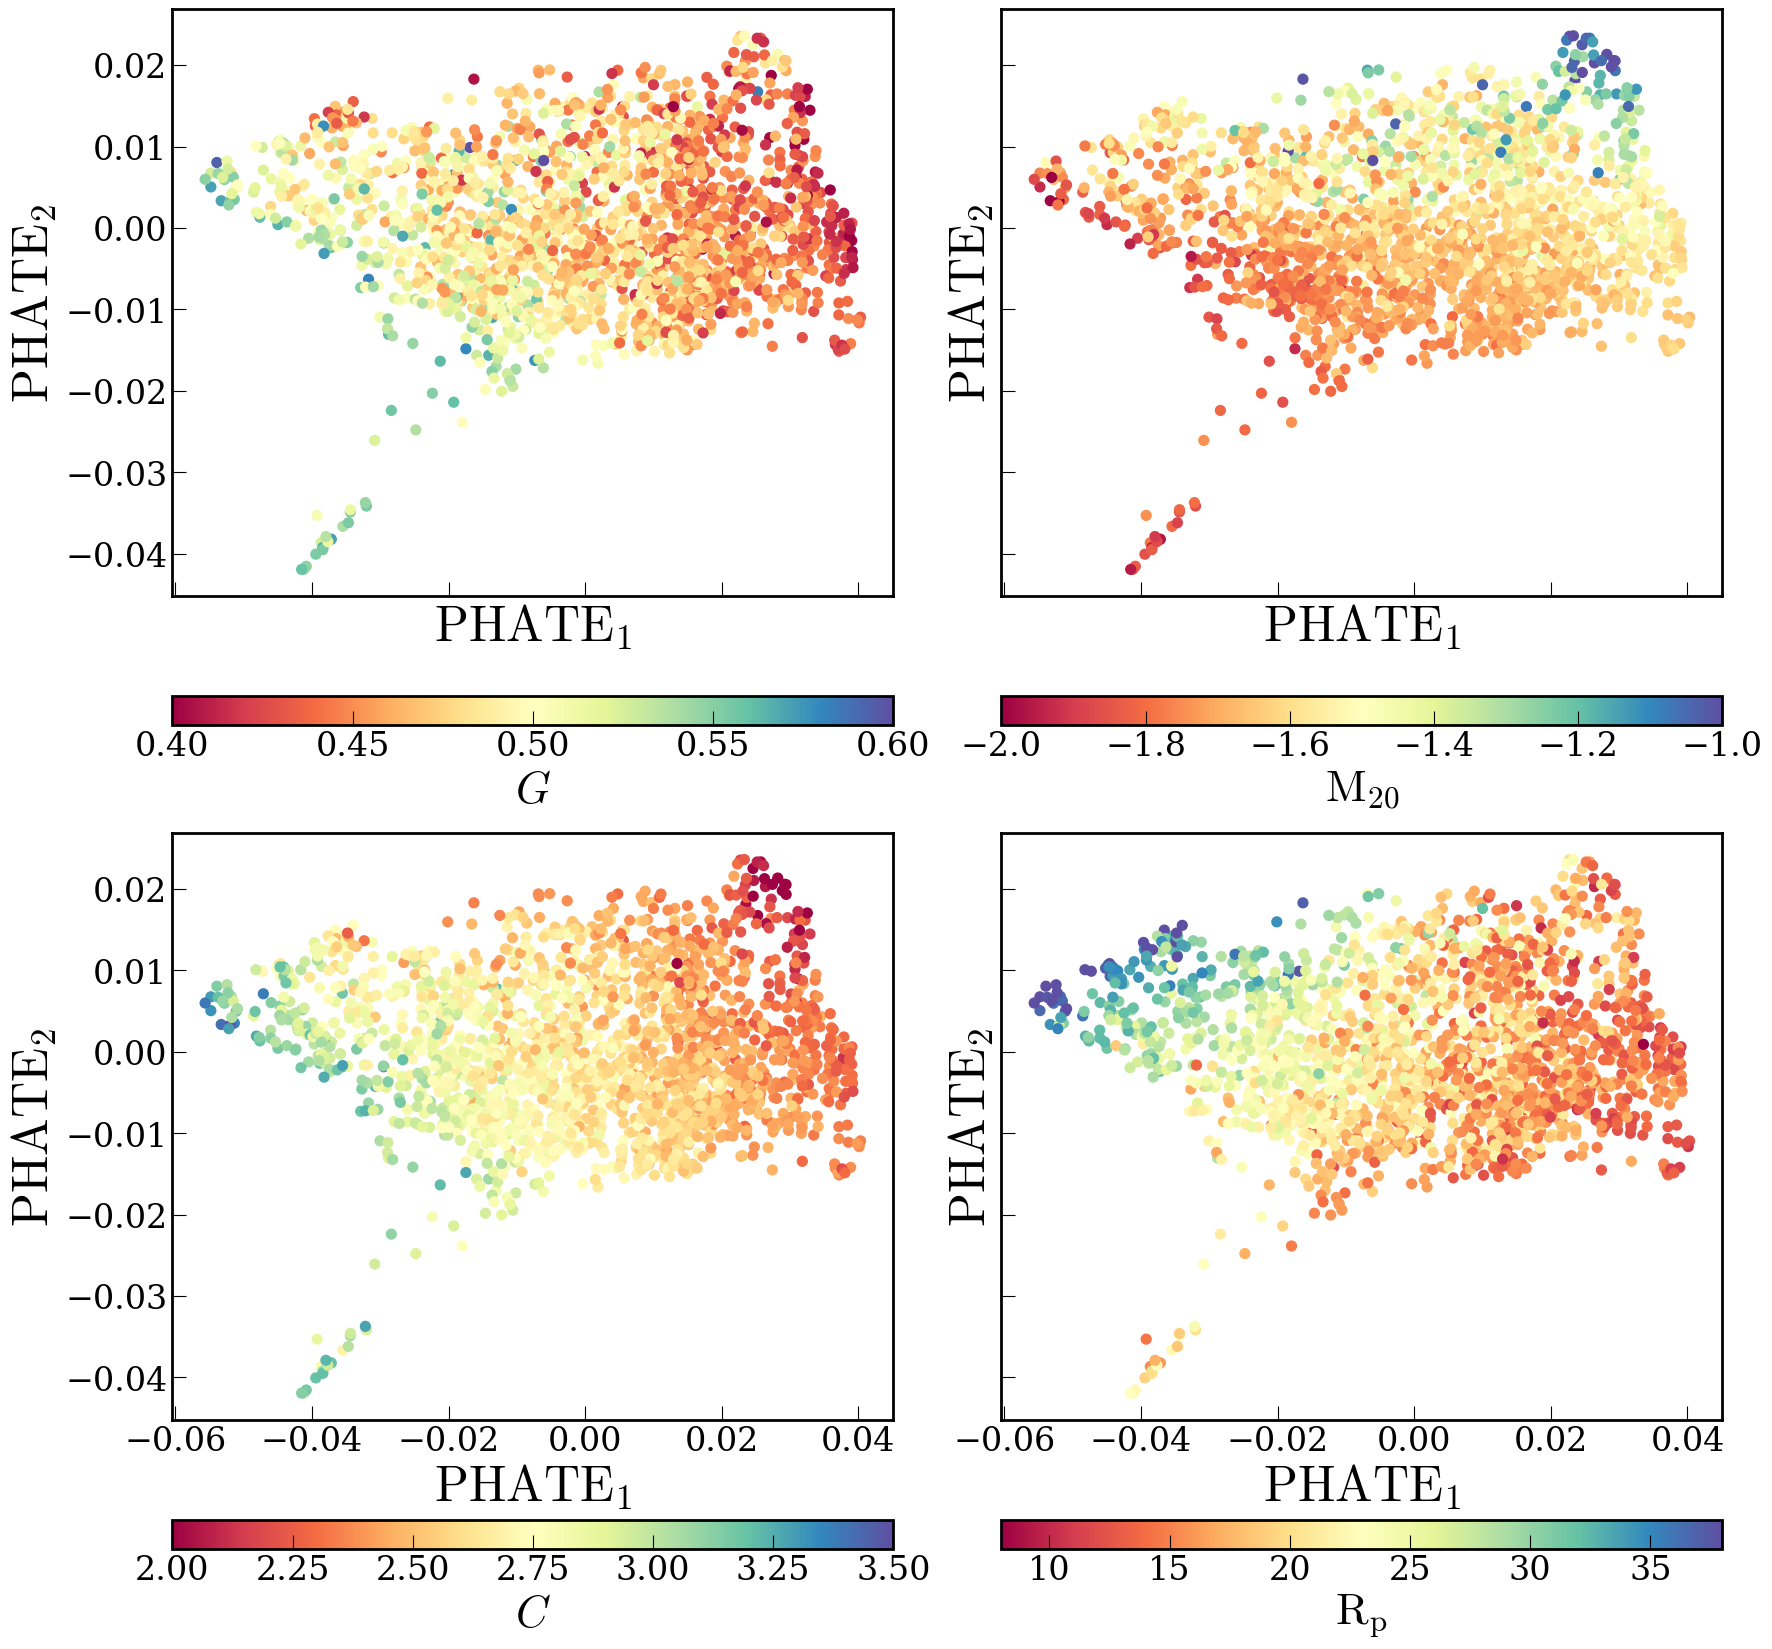

In [16]:
fig,ax=plt.subplots(2,2,figsize=(20,20),sharey='row',sharex='col')

key_list = list(npr.keys())
target_key = ['gini','m20','c','rpetro']
key_position = [key_list.index(t) for t in target_key]
    
for j,ley in enumerate(key_position):
    im = ax[j//2,j%2].scatter(Y[:,0],Y[:,1],c=selc[target_key[j]+'_r' ],cmap=mcm.Spectral,vmin=npr[key_list[ley]][0][0],vmax=npr[key_list[ley]][0][1],s=50)
    ax[j//2,j%2].set_rasterized(True)
    ax[j//2,j%2].set_xlabel(r'$PHATE_1$',fontsize=36)
    ax[j//2,j%2].set_ylabel(r'$PHATE_2$',fontsize=36)

    divider = make_axes_locatable(ax[j//2,j%2])
    cax = divider.append_axes('bottom', size='5%', pad=1.0)
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label(label=npr[key_list[ley]][2],size=32)

plt.subplots_adjust(hspace=0.15,wspace=0.15)
#plt.savefig('UMAP.pdf',bbox_inches='tight')